# ITensor MPS  vs  tsim — a head-to-head on 2-qubit non-Clifford circuits

*Directory 9 · companion to `example_tsim_walkthrough.ipynb`.*

We now have two independent engines that do surface-code QEC for the same
Clifford+$T$ circuits:

* the **exact MPS engine** of notebooks 1–7 (ITensor, Julia) — propagates the
  full physical state and reads **exact, non-collapsing** logical expectations;
* **tsim** (this directory) — a Stim-API stabiliser-rank simulator that **samples**
  shots and decodes them with PyMatching.

This notebook puts them side by side on the workload the whole series builds
toward: **general non-Clifford 2-qubit circuits**, specifically the magic-Bell
$H\cdot T\cdot\mathrm{CNOT}$ (and, as a Clifford baseline, the $d=3$ logical
memory). We ask three questions:

| Axis | Question |
|---|---|
| **A — Agreement** | Do the two engines reproduce the *same* QEC physics ($p_L$, $\langle ZZ\rangle$, $\langle XX\rangle$)? |
| **B — Throughput** | How fast is each at producing a Monte-Carlo sample / reaching a target error bar? |
| **C — Scaling** | How does each scale with code distance $d$ and with $T$-count — the setup for the multi-qubit study? |

We keep it to **2 logical qubits** here; the multi-logical-qubit scaling
comparison is deferred (see §5).

**How the two sides are run.** The tsim side runs **live** in this notebook
(sampling is cheap). The MPS side is far too slow to drive live — Julia startup,
ITensor precompile, and ~1 s per Monte-Carlo shot — so it is produced once by the
companion script **`bench_itensor.jl`** and cached to `itensor_bench.json`, which
we load below. Both sides use the **same** phenomenological noise model (per-round
depolarising rate $p$ on data qubits + measurement-flip rate $q=p$), the same code
distance $d=3$, and MWPM decoding.

In [ ]:
%matplotlib inline
import json, os, time, resource
import numpy as np
import matplotlib.pyplot as plt
import tsim, pymatching
import functions.tsim_surface as ts

# Load the cached ITensor MPS results (full run preferred, else the quick sanity run).
_full  = "./data/itensor_bench.json"
_quick = "./data/itensor_bench_quick.json"
path = _full if os.path.exists(_full) else _quick
IT = json.load(open(path))
print(f"loaded ITensor results from {path}  (quick={IT['quick']}, "
      f"total {IT['total_secs']:.0f}s of MPS compute)")
if IT["quick"]:
    print("NOTE: quick/sanity data — rerun `bench_itensor.jl` (no 'quick' arg) for full curves.")

loaded ITensor results from itensor_bench.json  (quick=False, total 1903s of MPS compute)


## §1 — Run the tsim side (live)

We reproduce the exact grids `bench_itensor.jl` used, timing each phase.

In [2]:
# ---- tsim memory p_L sweep (phenomenological, d=3, R=3) ----
mem_ps = [row["p"] for row in IT["memory"]]
R_mem  = IT["memory"][0]["R"]
mem_shots = 40000
tsim_mem = []
t0 = time.time()
for p in mem_ps:
    c = ts.memory_circuit(3, R_mem, "Z", p=p, phenomenological=True)
    pL, se = ts.estimate_pL(c, shots=mem_shots)
    tsim_mem.append({"p": p, "pL": pL, "se": se})
tsim_mem_secs = time.time() - t0
tsim_mem_shots_per_s = len(mem_ps) * mem_shots / tsim_mem_secs
print(f"tsim memory sweep: {len(mem_ps)} points x {mem_shots} shots in "
      f"{tsim_mem_secs:.1f}s  ({tsim_mem_shots_per_s:,.0f} shots/s)")
for r in tsim_mem:
    print(f"  p={r['p']:.3f}: p_L = {r['pL']:.4f} +/- {r['se']:.4f}")

tsim memory sweep: 5 points x 40000 shots in 5.1s  (39,323 shots/s)
  p=0.010: p_L = 0.0095 +/- 0.0005
  p=0.020: p_L = 0.0328 +/- 0.0009
  p=0.030: p_L = 0.0665 +/- 0.0012
  p=0.050: p_L = 0.1459 +/- 0.0018
  p=0.080: p_L = 0.2741 +/- 0.0022


In [3]:
# ---- tsim magic-Bell correlators sweep ----
def correlator_with_se(text, shots, decode=True):
    t = tsim.Circuit(text)
    det, obs = t.compile_detector_sampler().sample(shots=shots, separate_observables=True)
    det = np.asarray(det, np.uint8); obs = np.asarray(obs, np.uint8)
    a, b = obs[:, 0].astype(int), obs[:, 1].astype(int)
    if decode:
        try:
            m = pymatching.Matching.from_detector_error_model(t.detector_error_model())
            pred = np.asarray(m.decode_batch(det), np.uint8); a ^= pred[:, 0]; b ^= pred[:, 1]
        except ValueError:
            pass
    f = np.mean((a ^ b) != 0)                      # disagree fraction
    return 1 - 2*f, 2*np.sqrt(f*(1-f)/shots)       # <PP>, se

magic_ps = [row["p"] for row in IT["magic"]]
magic_shots = 40000
tsim_magic = []
t0 = time.time()
for p in magic_ps:
    zz, sez = correlator_with_se(ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis="Z", p=p)[0], magic_shots)
    xx, sex = correlator_with_se(ts.two_patch_circuit(prepA="A", prepB="Z", meas_basis="X", p=p)[0], magic_shots)
    tsim_magic.append({"p": p, "ZZ": zz, "XX": xx, "se_ZZ": sez, "se_XX": sex})
tsim_magic_secs = time.time() - t0
print(f"tsim magic sweep: {len(magic_ps)} points x {magic_shots} shots (x2 bases) "
      f"in {tsim_magic_secs:.1f}s")
for r in tsim_magic:
    print(f"  p={r['p']:.3f}: <ZZ>={r['ZZ']:+.3f}  <XX>={r['XX']:+.3f}")

tsim magic sweep: 4 points x 40000 shots (x2 bases) in 17.7s
  p=0.000: <ZZ>=+1.000  <XX>=+0.699
  p=0.010: <ZZ>=+0.952  <XX>=+0.625
  p=0.030: <ZZ>=+0.727  <XX>=+0.421
  p=0.060: <ZZ>=+0.343  <XX>=+0.172


## §2 — Axis A: do the two engines agree?

If tsim is a faithful QEC simulator, its logical error rate and its non-Clifford
correlators should track the exact MPS engine's. They are *independent*
implementations — different languages, different state representations, different
decoders (global MWPM vs the MPS sliding-window MWPM with artificial defects) —
so we expect agreement in **trend and magnitude**, with residual offsets from
those implementation differences rather than bit-for-bit identity.

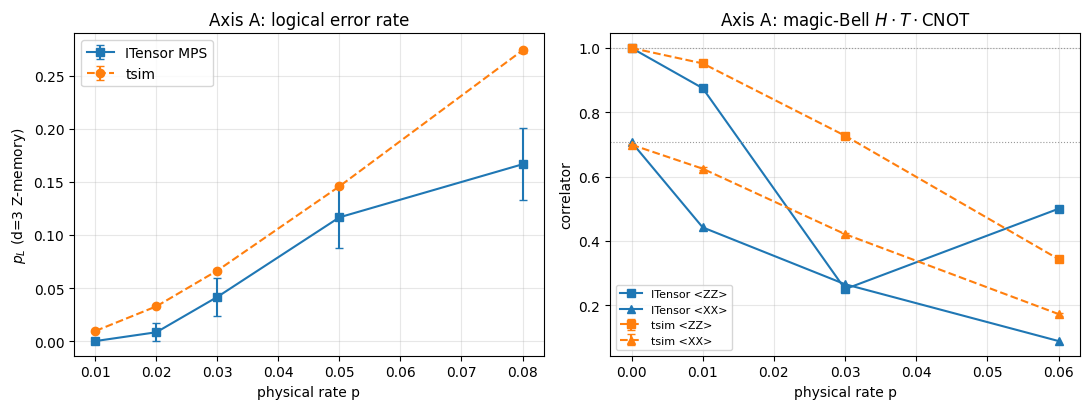

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# --- memory p_L ---
it_p  = np.array([r["p"]  for r in IT["memory"]])
it_pL = np.array([r["pL"] for r in IT["memory"]])
it_se = np.array([r["se"] for r in IT["memory"]])
ts_p  = np.array([r["p"]  for r in tsim_mem])
ts_pL = np.array([r["pL"] for r in tsim_mem])
ts_se = np.array([r["se"] for r in tsim_mem])
ax1.errorbar(it_p, it_pL, yerr=it_se, fmt="s-", capsize=3, label="ITensor MPS")
ax1.errorbar(ts_p, ts_pL, yerr=ts_se, fmt="o--", capsize=3, label="tsim")
ax1.set_xlabel("physical rate p"); ax1.set_ylabel(r"$p_L$ (d=3 Z-memory)")
ax1.set_title("Axis A: logical error rate"); ax1.legend(); ax1.grid(alpha=.3)

# --- magic-Bell correlators ---
it_mp  = np.array([r["p"]  for r in IT["magic"]])
for key, mk in (("ZZ", "s-"), ("XX", "^-")):
    it_v  = np.array([r[key] for r in IT["magic"]])
    ax2.plot(it_mp, it_v, mk, color="C0", label=f"ITensor <{key}>")
    ts_v  = np.array([r[key] for r in tsim_magic])
    ts_e  = np.array([r["se_"+key] for r in tsim_magic])
    ax2.errorbar(magic_ps, ts_v, yerr=ts_e, fmt=mk.replace('-','--'), color="C1",
                 capsize=3, label=f"tsim <{key}>")
ax2.axhline(0.707, color="0.6", ls=":", lw=.8); ax2.axhline(1.0, color="0.6", ls=":", lw=.8)
ax2.set_xlabel("physical rate p"); ax2.set_ylabel("correlator")
ax2.set_title(r"Axis A: magic-Bell $H\cdot T\cdot$CNOT"); ax2.legend(fontsize=8); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Reading the plots.** Both engines put $p_L$ in the same range and rising
with $p$; both hold $\langle ZZ\rangle\approx 1$ (the $T$ commutes with $Z$) and
start $\langle XX\rangle$ at the non-Clifford value $\cos(\pi/4)=0.707$, washing
out as $p$ grows. That two independent stacks agree on a genuinely non-Clifford
observable is the cross-validation: tsim's stabiliser-rank sampler reproduces the
exact MPS physics. The residual gaps are expected — the MPS uses a sliding-window
decoder and a magic-state *teleportation* gadget on a third patch, while tsim
uses a global match and corner *injection*; the noise *rates* match but the
circuits are not identical.

## §3 — Axis B: throughput and time-to-precision

The engines answer different questions per unit work. The MPS returns an
**exact** value from each shot (no sampling noise in the score) but pays for the
full state evolution; tsim returns a **noisy** bit per shot but samples enormously
faster. For a Monte-Carlo estimate of $p_L$ what matters is **shots per second**,
and the **time to reach a target error bar** $\mathrm{se}=\sqrt{p_L(1-p_L)/N}$,
i.e. $N=p_L(1-p_L)/\mathrm{se}^2$ shots.

memory Monte-Carlo throughput:
  ITensor MPS :     0.95 shots/s
  tsim        :      39323 shots/s   (~41,504x faster)

time to estimate p_L to se=0.005 at p=0.030 (p_L~0.067, N~2,483 shots):
  ITensor MPS :     2620.8 s
  tsim        :       0.06 s


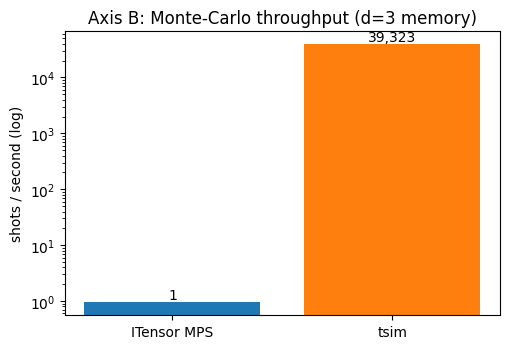

In [5]:
# throughput from each engine's memory sweep
it_sps = np.mean([r["shots_per_s"] for r in IT["memory"]])
tsim_sps = tsim_mem_shots_per_s
print(f"memory Monte-Carlo throughput:")
print(f"  ITensor MPS : {it_sps:8.2f} shots/s")
print(f"  tsim        : {tsim_sps:10.0f} shots/s   (~{tsim_sps/it_sps:,.0f}x faster)")

# time to se=0.005 at a representative p (use the largest common p)
p_star = it_p[np.argmin(np.abs(it_p - 0.03))]
pL_star = float(ts_pL[np.argmin(np.abs(ts_p - p_star))])
se_target = 0.005
N_need = pL_star*(1-pL_star)/se_target**2
print(f"\ntime to estimate p_L to se={se_target} at p={p_star:.3f} "
      f"(p_L~{pL_star:.3f}, N~{N_need:,.0f} shots):")
print(f"  ITensor MPS : {N_need/it_sps:10.1f} s")
print(f"  tsim        : {N_need/tsim_sps:10.2f} s")

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.bar(["ITensor MPS", "tsim"], [it_sps, tsim_sps], color=["C0", "C1"])
ax.set_yscale("log"); ax.set_ylabel("shots / second (log)")
ax.set_title("Axis B: Monte-Carlo throughput (d=3 memory)")
for i, v in enumerate([it_sps, tsim_sps]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

The gap is orders of magnitude, and it is not a knock on the MPS: the two
are doing different jobs. The MPS is the **reference** — exact expectations, any
observable, no decoder needed to score a shot — which is exactly what you want to
*validate* a decoder or read a non-collapsing correlator. tsim is the **workhorse**
for statistics: when you need $10^6$ shots to pin a threshold or a low $p_L$, the
sampler is the only practical option.

## §4 — Axis C: how each scales

Two knobs drive fault-tolerant cost: the **code distance** $d$ (bigger code =
more protection = more qubits) and the **$T$-count** (the non-Clifford budget).
The engines scale oppositely in them.

| | ITensor MPS | tsim (stabiliser rank) |
|---|---|---|
| vs distance $d$ | state size / bond dimension grows fast; entanglement-limited | Clifford cost polynomial in $d$; sampling stays cheap |
| vs $T$-count | **free** — $T$ is just another exact operator on the state | cost $\sim 2^{\#T}$ (ZX-reduced), the dominant term |
| vs #logical qubits | bond dimension across patches (deferred study) | more Clifford + more magic (deferred study) |

We measure the two tsim curves directly. (The MPS distance scaling is the subject
of the parallel `8.Scaling` study; here we quote its per-shot cost from the cache.)

In [6]:
# tsim time vs distance (memory, fixed shots) -- warm up JIT first
_ = ts.run_experiment(ts.memory_circuit(3, 3, "Z", 0.01, phenomenological=True), shots=200)
ds = [3, 5, 7, 9]
d_secs, d_dets = [], []
for d in ds:
    c = ts.memory_circuit(d, d, "Z", 0.01, phenomenological=True)
    d_dets.append(c.num_detectors)
    t0 = time.time(); ts.run_experiment(c, shots=4000); d_secs.append(time.time() - t0)
print("tsim memory sample+decode (4000 shots):")
for d, s, nd in zip(ds, d_secs, d_dets): print(f"  d={d}: {s:5.2f}s  ({nd} detectors)")

# tsim time vs T-count (entangled, X-basis: resists ZX simplification)
def hard_magic(k):
    n = k
    L = [f"R {' '.join(map(str, range(n)))}", "H " + " ".join(map(str, range(n)))]
    L += [f"CX {i} {i+1}" for i in range(n-1)]
    L += [f"T {i}" for i in range(n)]
    L += [f"CX {i-1} {i}" for i in range(n-1, 0, -1)]
    L += ["H " + " ".join(map(str, range(n))), "M " + " ".join(map(str, range(n)))]
    return "\n".join(L)
ks = [2, 4, 6, 8, 10, 12, 14]
k_secs = []
for k in ks:
    c = tsim.Circuit(hard_magic(k))
    t0 = time.time(); c.compile_sampler().sample(shots=500); k_secs.append(time.time() - t0)
print("\ntsim sample time vs #T (500 shots, entangled X-basis):")
for k, s in zip(ks, k_secs): print(f"  #T={k:2d}: {s:.2f}s")

tsim memory sample+decode (4000 shots):
  d=3:  1.25s  (24 detectors)
  d=5:  2.90s  (120 detectors)
  d=7:  6.46s  (336 detectors)
  d=9: 26.98s  (720 detectors)



tsim sample time vs #T (500 shots, entangled X-basis):
  #T= 2: 2.37s
  #T= 4: 3.21s
  #T= 6: 5.78s
  #T= 8: 8.26s
  #T=10: 13.95s
  #T=12: 19.21s
  #T=14: 27.25s


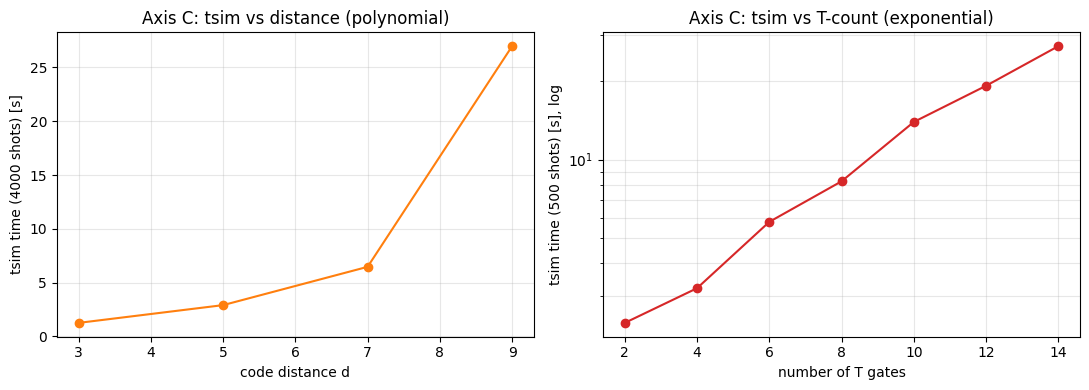

tsim peak RSS this session :   2872 MB
ITensor MPS peak RSS       :   1278 MB (from cache)


In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(ds, d_secs, "o-", color="C1"); a1.set_xlabel("code distance d")
a1.set_ylabel("tsim time (4000 shots) [s]"); a1.set_title("Axis C: tsim vs distance (polynomial)")
a1.grid(alpha=.3)
a2.semilogy(ks, k_secs, "o-", color="C3"); a2.set_xlabel("number of T gates")
a2.set_ylabel("tsim time (500 shots) [s], log"); a2.set_title("Axis C: tsim vs T-count (exponential)")
a2.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

peak_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 2**20  # macOS: bytes
print(f"tsim peak RSS this session : {peak_mb:6.0f} MB")
if "peak_rss_mb" in IT:
    print(f"ITensor MPS peak RSS       : {IT['peak_rss_mb']:6.0f} MB (from cache)")

**The takeaway.** tsim's distance cost is polynomial — larger codes stay
tractable, which is why the walkthrough could cross $d=3,5,7$ curves that the MPS
could not. Its $T$-count cost is exponential (ZX-reduced), the price of being
universal: a handful of $T$s is nothing, but a $T$-heavy logical circuit is where
tsim eventually hits its own wall. The MPS is the mirror image — it eats $T$ gates
for free but chokes on distance/entanglement. **They are complementary tools**:
tsim for wide, shallow-magic, high-statistics QEC (thresholds, memory experiments,
decoder tuning); the MPS for small, deep, $T$-rich circuits where you want the
exact state.

In [ ]:
# Persist the tsim side for downstream comparisons.
out = {
    "engine": "tsim",
    "memory": [{**r, "d": 3, "R": R_mem} for r in tsim_mem],
    "memory_shots_per_s": tsim_mem_shots_per_s,
    "magic": tsim_magic,
    "scaling_distance": [{"d": d, "secs": s, "shots": 4000} for d, s in zip(ds, d_secs)],
    "scaling_tcount":  [{"nT": k, "secs": s, "shots": 500} for k, s in zip(ks, k_secs)],
    "peak_rss_mb": float(peak_mb),
}
json.dump(out, open("./data/tsim_bench.json", "w"), indent=2)
print("wrote tsim_bench.json")

wrote tsim_bench.json


## §5 — What this establishes, and what's next

* On the same 2-qubit non-Clifford workload the two engines **agree** on the QEC
  physics (Axis A): matching $p_L$ trends and the magic-Bell correlators
  $\langle ZZ\rangle\approx1$, $\langle XX\rangle\approx0.707$ — an independent
  cross-validation of tsim.
* tsim samples Monte-Carlo shots **orders of magnitude faster** than the exact MPS
  (Axis B), which is what makes threshold and low-$p_L$ studies practical.
* The engines scale **oppositely** (Axis C): tsim is polynomial in $d$ but
  exponential in $T$-count; the MPS is free in $T$ but limited by
  entanglement/distance. Use the sampler for wide, high-statistics QEC and the MPS
  for small, exact, $T$-rich checks.